In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr

import utils

### Read spatially averaged daily mean surface wind speed data files

In [2]:
model_infile = '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_CanESM5-dcppA-hindcast_196101-201701_MJJ_nem-2030.nc'
obs_infile = '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_BARRA-R2_1980-2025_MJJ_nem-2030.nc'

In [3]:
ds_model = xr.open_dataset(model_infile)
ds_model = ds_model.compute()

In [4]:
ds_model

<xarray.Dataset> Size: 9MB
Dimensions:    (init_date: 57, ensemble: 20, lead_time: 920)
Coordinates:
  * ensemble   (ensemble) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * lead_time  (lead_time) int64 7kB 0 1 2 3 4 5 6 ... 914 915 916 917 918 919
  * init_date  (init_date) object 456B 1961-05-01 00:00:00 ... 2017-05-01 00:...
    time       (lead_time, init_date) object 420kB 1961-05-01 12:00:00 ... 20...
Data variables:
    sfcWind    (init_date, ensemble, lead_time) float64 8MB 3.944 3.93 ... 4.78
Attributes: (12/53)
    CCCma_model_hash:            Unknown
    CCCma_parent_runid:          d2a-asm-e01
    CCCma_pycmor_hash:           13db8596c37129e414cad7ae31f2927ca8f5dd39
    CCCma_runid:                 d2a196101e01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1961:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/06d13276-8392-455a-90a3-8583122...
    variable_id:                 sfcWind
    variant_label:               r1i1p2f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

In [5]:
ds_obs = xr.open_dataset(obs_infile)
ds_obs = ds_obs.compute()

In [6]:
ds_obs

<xarray.Dataset> Size: 68kB
Dimensions:  (time: 4232)
Coordinates:
  * time     (time) datetime64[ns] 34kB 1980-05-01T12:00:00 ... 2025-07-31T12...
Data variables:
    sfcWind  (time) float64 34kB 3.886 4.319 4.307 4.119 ... 2.612 3.348 3.062
Attributes: (12/61)
    CDI:                       Climate Data Interface version 2.4.3 (https://...
    Conventions:               CF-1.10, ACDD-1.3
    source:                    Data from Met Office Unified Model (UM, versio...
    institution:               Bureau of Meteorology
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    ...                        ...
    geospatial_lat_units:      degrees_north
    geospatial_lon_min:        88.48
    geospatial_lon_max:        207.39
    geospatial_lon_units:      degrees_east
    history:                   Mon May 11 11:26:42 2026: cdo mergetime sfcWin...
    CDO:                       Climate Data Operators version 2.4.3 (https://...

In [7]:
sfcWind_model_data = ds_model['sfcWind'].stack({'sample': ['ensemble', 'init_date', 'lead_time']}).values

In [8]:
sfcWind_obs_data = ds_obs['sfcWind'].values

### Calculate 10th percentile

In [9]:
pctl10_model = np.percentile(sfcWind_model_data, 10)

In [10]:
print(pctl10_model)

3.536619275782543


In [11]:
pctl10_obs = np.percentile(sfcWind_obs_data, 10)

In [12]:
pctl10_obs

np.float64(2.8578365490351456)

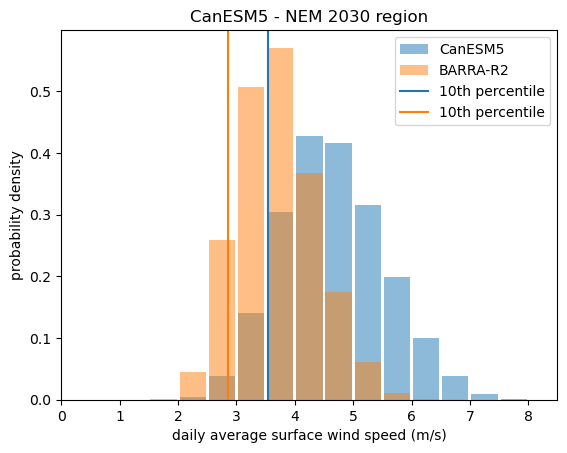

In [13]:
bins = np.arange(0, 9.5, 0.5)
plt.hist(sfcWind_model_data, bins=bins, density=True, rwidth=0.9, label='CanESM5', color='tab:blue', alpha=0.5)
plt.hist(sfcWind_obs_data, bins=bins, density=True, rwidth=0.9, label='BARRA-R2', color='tab:orange', alpha=0.5)
plt.axvline(pctl10_model, color='tab:blue', label='10th percentile')
plt.axvline(pctl10_obs, color='tab:orange', label='10th percentile')
plt.xlabel('daily average surface wind speed (m/s)')
plt.ylabel('probability density')
plt.title('CanESM5 - NEM 2030 region')
plt.xlim(0, 8.5)
plt.legend()
plt.show()

### Calculate annual maximum wind drought duration (WDDx)

In [14]:
wddx_model = utils.calc_wddx_model(ds_model, pctl10_model)

In [15]:
wddx_model

<xarray.Dataset> Size: 183kB
Dimensions:       (ensemble: 20, init_date: 57, lead_time: 10)
Coordinates:
  * ensemble      (ensemble) int64 160B 0 1 2 3 4 5 6 7 ... 13 14 15 16 17 18 19
  * init_date     (init_date) object 456B 1961-05-01 00:00:00 ... 2017-05-01 ...
  * lead_time     (lead_time) int64 80B 1 2 3 4 5 6 7 8 9 10
Data variables:
    event_start   (ensemble, init_date, lead_time) object 91kB 1961-06-28 12:...
    event_length  (ensemble, init_date, lead_time) float64 91kB 3.0 2.0 ... 3.0

In [16]:
wddx_obs = utils.calc_wddx_obs(ds_obs, pctl10_obs)

In [17]:
wddx_obs

<xarray.Dataset> Size: 736B
Dimensions:       (event_start: 46)
Coordinates:
  * event_start   (event_start) datetime64[ns] 368B 1980-05-30T12:00:00 ... 2...
Data variables:
    event_length  (event_start) float64 368B 2.0 1.0 3.0 1.0 ... 3.0 2.0 2.0 3.0

In [20]:
years = wddx_obs['event_start'].dt.year.values
df = pd.DataFrame(index=years)
df['WDDx'] = wddx_obs['event_length'].values
df['start_date'] = wddx_obs['event_start'].dt.strftime('%Y-%m-%d')
df.sort_values(['WDDx'], ascending=False).head(n=10)

,WDDx,start_date
1997,9.0,1997-05-16
2002,8.0,2002-05-22
2010,8.0,2010-05-14
2005,6.0,2005-05-14
1992,5.0,1992-05-14
2000,5.0,2000-07-06
1995,5.0,1995-05-17
2001,5.0,2001-05-01
2006,5.0,2006-07-23
1993,4.0,1993-07-14


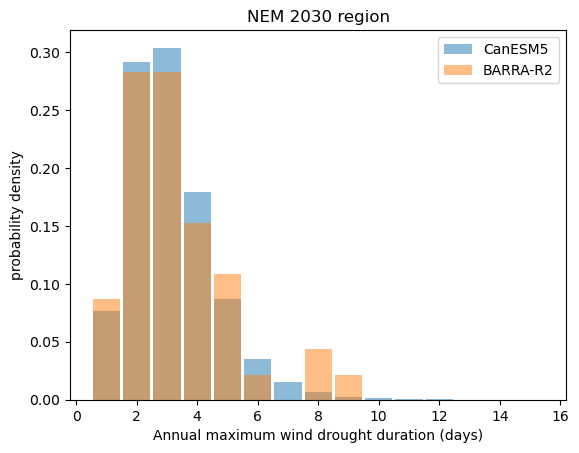

In [21]:
bins = np.arange(0.5, 16.5, 1)
plt.hist(
    wddx_model['event_length'].values.flatten(),
    bins=bins,
    density=True,
    rwidth=0.9,
    label='CanESM5',
    color='tab:blue',
    alpha=0.5
)
plt.hist(
    wddx_obs['event_length'].values,
    bins=bins,
    density=True,
    rwidth=0.9,
    label='BARRA-R2',
    color='tab:orange',
    alpha=0.5
)
plt.xlabel('Annual maximum wind drought duration (days)')
plt.ylabel('probability density')
plt.title('NEM 2030 region')
plt.legend()
plt.show()

In [22]:
np.nanmax(wddx_model['event_length'].values)

np.float64(15.0)

In [23]:
np.nanmax(wddx_obs['event_length'].values)

np.float64(9.0)